# Loading a ucl-open dataset

This notebook shows how to load raw data from a ucl-open dataset into pandas data frames using the
[swc-aeon](https://github.com/SainsburyWellcomeCentre/aeon_api) API.

Datasets logged following the [logging specification](../../specs/logging.md) can be read directly with
`swc.aeon.io.api.load`. ucl-open only adds readers for formats that are specific to ucl-open:

- `ucl_open.io.reader.Harp`: reads a single Harp register, decoded with [harp-python](https://github.com/harp-tech/python)
  using the device schema (`device.yml`).
- `ucl_open.io.reader.RawVideo`: reads frame metadata for videos logged with `LogRawVideo`.
- `ucl_open.io.streams`: stream factories for declaring each device in the experiment:
  - `harp_device`: a Harp device, with one data stream per register.
  - `csv`: a single-stream device logged as CSV files, read with the standard aeon `Csv` reader.
  - `raw_video`: a video device logged with `LogRawVideo`.

The example dataset was collected with `src/UclOpen.Logging.Tests/LogDummyDataset.bonsai`.

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import swc.aeon.io.api as aeon
from dotmap import DotMap
from swc.aeon.io.video import frames
from swc.aeon.schema.streams import Device

from ucl_open.io.streams import csv, harp_device, raw_video

## Dataset location

`root` can be a single session directory, or any parent directory (for example a subject directory) to stitch
together data from several sessions.

Harp devices need the device schema to decode registers. The logging specification requires it to be saved as
`<Device>/<Device>.yml`. If it is not present, the schema for the Harp Behavior board is downloaded from
[harp-tech/device.behavior](https://github.com/harp-tech/device.behavior).

In [3]:
root = Path(r"C:\temp_data\sub-DataMouse\ses-001_date-2026-10-03T16-14-20")

device_yml = root / "HarpDevice" / "HarpDevice.yml"
if not device_yml.exists():
    device_yml, _ = urlretrieve(
        "https://raw.githubusercontent.com/harp-tech/device.behavior/main/device.yml"
    )

## Declaring the experiment

Each `Device` maps a device directory to the readers for its data streams, created by a stream factory from
`ucl_open.io.streams`. Single-stream devices map the directory
name to a single reader, so the reader is accessed directly as `experiment.<Device>`. Multi-channel Harp devices
create one reader per register, accessed as `experiment.<Device>.<Register>`.

For `csv` devices, the `Seconds` column is always used as the time index, so `columns` names only the remaining
columns.

In [8]:
experiment = DotMap(
    [
        Device("HarpDevice", harp_device(device_yml)),
        Device("MousePosition", csv(columns=("x", "y", "z"))),
        Device("Video", raw_video()),
    ]
)

print(experiment.keys())

odict_keys(['HarpDevice', 'MousePosition', 'Video'])


## Loading data

`aeon.load` finds every chunk file for a stream, reads it, and stitches all chunks into a single data frame
indexed by time. Harp timestamps (seconds since 1904-01-01) are converted to UTC datetimes.

In [9]:
analog_data = aeon.load(root, experiment.HarpDevice.AnalogData)
analog_data.head()

,AnalogInput0,Encoder,AnalogInput1
time,,,
1904-01-01 00:00:00.260000+00:00,-4172,-1946,4279
1904-01-01 00:00:00.580000+00:00,30472,8304,14063
1904-01-01 00:00:01.130016+00:00,-4042,23815,28165
1904-01-01 00:00:01.529984+00:00,-731,-30654,-22128
1904-01-01 00:00:02.060000+00:00,-7952,26928,-23681


In [10]:
digital_inputs = aeon.load(root, experiment.HarpDevice.DigitalInputState)
digital_inputs.head()

,DIPort0,DIPort1,DIPort2,DI3
time,,,,
1904-01-01 00:00:01.080000+00:00,True,False,True,True
1904-01-01 00:00:02.980000+00:00,False,True,False,True
1904-01-01 00:00:03.350016+00:00,True,True,False,False
1904-01-01 00:00:03.410016+00:00,False,False,False,True
1904-01-01 00:00:03.580000+00:00,False,False,False,False


In [11]:
mouse_position = aeon.load(root, experiment.MousePosition)
mouse_position.head()

,x,y,z
time,,,
1904-01-01 00:00:00.070016+00:00,266,94,0
1904-01-01 00:00:00.070016+00:00,293,119,0
1904-01-01 00:00:00.070016+00:00,344,164,0
1904-01-01 00:00:00.070016+00:00,410,218,0
1904-01-01 00:00:00.080000+00:00,488,284,0


In [12]:
video = aeon.load(root, experiment.Video)
video.head()

,width,height,_frame,_path,_epoch
time,,,,,
1904-01-01 00:00:00.080000+00:00,640,480,0,C:\temp_data\sub-DataMouse\ses-001_date-2026-1...,ses-001_date-2026-10-03T16-14-20
1904-01-01 00:00:00.089984+00:00,640,480,1,C:\temp_data\sub-DataMouse\ses-001_date-2026-1...,ses-001_date-2026-10-03T16-14-20
1904-01-01 00:00:00.100000+00:00,640,480,2,C:\temp_data\sub-DataMouse\ses-001_date-2026-1...,ses-001_date-2026-10-03T16-14-20
1904-01-01 00:00:00.110016+00:00,640,480,3,C:\temp_data\sub-DataMouse\ses-001_date-2026-1...,ses-001_date-2026-10-03T16-14-20
1904-01-01 00:00:00.120000+00:00,640,480,4,C:\temp_data\sub-DataMouse\ses-001_date-2026-1...,ses-001_date-2026-10-03T16-14-20


## Selecting a time window

Pass `start` and `end` to load only the data in a time range. Only the chunk files overlapping the window are read.
Use `aeon.to_datetime` to convert from Harp seconds.

In [13]:
start = aeon.to_datetime(60.0)
end = aeon.to_datetime(120.0)
window = aeon.load(root, experiment.HarpDevice.AnalogData, start=start, end=end)
window.index.min(), window.index.max(), len(window)

(Timestamp('1904-01-01 00:01:00.800000+0000', tz='UTC'),
 Timestamp('1904-01-01 00:01:59.440000+0000', tz='UTC'),
 85)

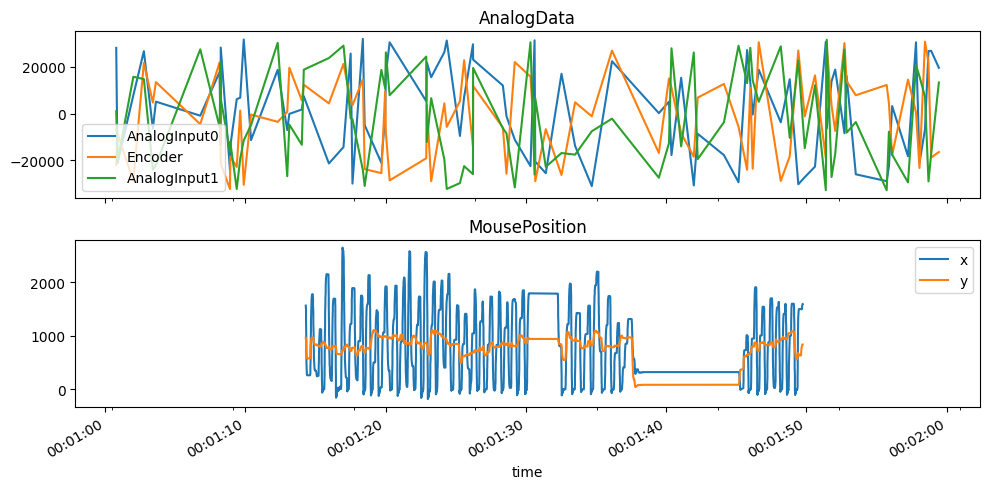

In [14]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
window.plot(ax=axes[0], title="AnalogData")
aeon.load(root, experiment.MousePosition, start=start, end=end)[["x", "y"]].plot(
    ax=axes[1], title="MousePosition"
)
plt.tight_layout()

## Reading video frames

`RawVideo` data frames include the video file path and frame index for each frame, so they work with the aeon video
helpers. Here the frame closest to each analog sample in the window is read from disk.

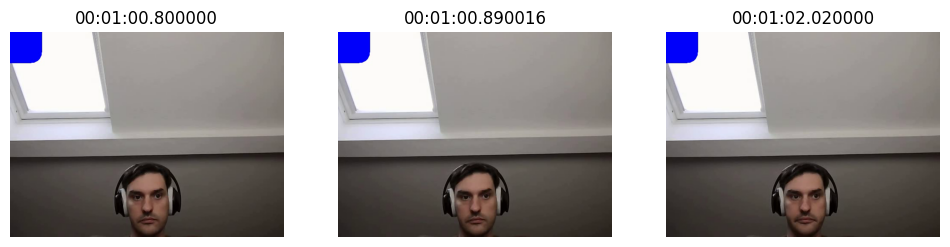

In [11]:
frame_times = video.index.get_indexer(window.index[:3], method="nearest")
images = list(frames(video.iloc[frame_times]))

fig, axes = plt.subplots(1, len(images), figsize=(12, 3))
for ax, image, time in zip(axes, images, window.index[:3]):
    ax.imshow(image[:, :, ::-1])
    ax.set_title(str(time.time()))
    ax.axis("off")

## Chunk sizes

aeon selects chunk files for a time window assuming one-hour chunks. Datasets logged with sub-hour chunks load
correctly. If a dataset was logged with `ChunkSize` greater than one hour, set the chunk duration before loading
a time window, otherwise data from a chunk starting before `start` may be missed:

```python
aeon.CHUNK_DURATION = 2  # hours
```